# Filter Bank CSP Cross-Subject Motor Imagery Benchmark

## Context

This notebook extends the baseline CSP + LDA experiment with a **Filter Bank CSP + LDA** pipeline.

**Model:** FBCSP (Filter Bank Common Spatial Patterns) + LDA (Linear Discriminant Analysis)  
**Evaluation:** Cross-subject (train on all subjects except one, test on held-out subject)  
**Dataset:** BNCI2014_001 (9 subjects, 2 sessions, left vs right hand motor imagery)  

**Why this matters:** 
Instead of one wide frequency range, the model uses multiple narrow motor-imagery bands, extracts CSP features per band, concatenates them, and classifies with LDA.

The objective is to test whether richer spectral representation can improve cross-subject generalization, especially for weaker subjects.

# 1. Setup

## 1.1. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import builtins
import json
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import mne
import moabb

# MOABB imports
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from moabb.evaluations import CrossSubjectEvaluation

# MNE for CSP and filtering
from mne.decoding import CSP
from mne.filter import filter_data

# scikit-learn imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

PACKAGE VERSIONS
Python: 3.11.15
numpy: 2.4.3
pandas: 3.0.1
matplotlib: 3.10.8
sklearn: 1.8.0
mne: 1.11.0
moabb: 1.4.3


## 1.2. Create artifact directory

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
ARTIFACT_DIR = BASE_DIR / 'artifacts' / '03_fbcsp_lda'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Artifact directory: {ARTIFACT_DIR}')

Artifact directory: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_fbcsp_lda


## 1.3. Initialize Logger

In [3]:
LOG_PATH = ARTIFACT_DIR / 'run.log'
if '_LOG_FILE_HANDLE' in globals() and _LOG_FILE_HANDLE and not _LOG_FILE_HANDLE.closed:
    _LOG_FILE_HANDLE.close()
_LOG_FILE_HANDLE = open(LOG_PATH, 'w', buffering=1, encoding='utf-8')

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop('sep', ' ')
    end = kwargs.pop('end', '\n')
    flush = kwargs.pop('flush', False)
    file = kwargs.pop('file', None)

    message = sep.join(str(arg) for arg in args)
    leading_newlines = len(message) - len(message.lstrip('\n'))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text)
            if flush:
                sys.__stdout__.flush()
        else:
            file.write(text)
            if flush and hasattr(file, 'flush'):
                file.flush()

    if leading_newlines > 0:
        blanks = '\n' * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        stamped = f'[{ts}] {message_body}'
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

print(f'Logging to: {LOG_PATH}')

[2026-04-14 10:10:43] Logging to: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_fbcsp_lda/run.log


## 1.4. Save Artifacts

In [4]:
def save_plot(filename):
    path = ARTIFACT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')

def save_table(data, filename, index=False):
    path = ARTIFACT_DIR / filename
    suffix = path.suffix.lower()

    if suffix == '.csv':
        if isinstance(data, pd.Series):
            data = data.to_frame()
        data.to_csv(path, index=index)
    elif suffix == '.json':
        if isinstance(data, pd.DataFrame):
            data.to_json(path, orient='records', indent=2)
        else:
            with open(path, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2)
    else:
        raise ValueError(f'Unsupported file extension: {suffix}')

    print(f'Saved table: {path}')

def get_first_matching_column(frame, candidates):
    lower_lookup = {column.lower(): column for column in frame.columns}
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
        lowered = candidate.lower()
        if lowered in lower_lookup:
            return lower_lookup[lowered]
    raise KeyError(f'Expected one of {candidates}; available columns: {list(frame.columns)}')

# 2. Data

## 2.1. Dataset Setup

In [5]:
dataset = BNCI2014_001()
paradigm = LeftRightImagery()

print('Dataset and paradigm initialized.')
print(f'Dataset: {dataset.__class__.__name__}')
print(f'Paradigm: {paradigm.__class__.__name__}')

[2026-04-14 10:10:43] Dataset and paradigm initialized.
[2026-04-14 10:10:43] Dataset: BNCI2014_001
[2026-04-14 10:10:43] Paradigm: LeftRightImagery


## 2.2. Dataset Metadata Inspection

In [ ]:
print('=' * 60)
print('DATASET INFORMATION')
print('=' * 60)
print(f'Number of subjects: {len(dataset.subject_list)}')
print(f'Subject IDs: {dataset.subject_list}')
print(f'Number of sessions: {dataset.n_sessions}')
print(f'Event IDs (all classes): {dataset.event_id}')

[2026-04-14 10:10:43] ============================================================
[2026-04-14 10:10:43] DATASET INFORMATION
[2026-04-14 10:10:43] ============================================================
[2026-04-14 10:10:43] Number of subjects: 9
[2026-04-14 10:10:43] Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-14 10:10:43] Number of sessions: 2
[2026-04-14 10:10:43] Event IDs (all classes): {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}

[2026-04-14 10:10:43] ============================================================
[2026-04-14 10:10:43] PARADIGM INFORMATION
[2026-04-14 10:10:43] ============================================================
[2026-04-14 10:10:43] Frequency filters from paradigm: [[8, 32]]
[2026-04-14 10:10:43] Paradigm events (left/right only): ['left_hand', 'right_hand']


In [ ]:
print('\n' + '=' * 60)
print('PARADIGM INFORMATION')
print('=' * 60)

# Paradigm details
print(f'Frequency filters: {paradigm.filters}')
print(f'Paradigm events (left/right only): {paradigm.events}')

# 3. Filter Bank CSP + LDA Pipeline Definition

This implementation uses a compact filter bank over motor-imagery frequencies, fits one CSP model per band, concatenates all bandwise CSP features, and classifies with LDA.

## 3.1. Frequency Dands Definition

In [7]:
FREQUENCY_BANDS = [
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32),
]
CSP_COMPONENTS_PER_BAND = 2
TOTAL_FEATURE_DIM = len(FREQUENCY_BANDS) * CSP_COMPONENTS_PER_BAND

print('============================================================')
print('FBCSP CONFIGURATION')
print('============================================================')
print(f'Frequency bands: {FREQUENCY_BANDS}')
print(f'CSP components per band: {CSP_COMPONENTS_PER_BAND}')
print(f'Expected total feature dimension: {TOTAL_FEATURE_DIM}')

[2026-04-14 10:10:43] ============================================================
[2026-04-14 10:10:43] FBCSP CONFIGURATION
[2026-04-14 10:10:43] ============================================================
[2026-04-14 10:10:43] Frequency bands: [(8, 12), (12, 16), (16, 20), (20, 24), (24, 28), (28, 32)]
[2026-04-14 10:10:43] CSP components per band: 2
[2026-04-14 10:10:43] Expected total feature dimension: 12


In [8]:
class FilterBankCSPTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, bands=None, n_components=2, sfreq=250.0, filter_method='fir', random_state=42):
        self.bands = bands if bands is not None else [(8, 12), (12, 16), (16, 20), (20, 24), (24, 28), (28, 32)]
        self.n_components = n_components
        self.sfreq = sfreq
        self.filter_method = filter_method
        self.random_state = random_state

    def _filter_single_band(self, X, l_freq, h_freq):
        return filter_data(
            data=X,
            sfreq=self.sfreq,
            l_freq=l_freq,
            h_freq=h_freq,
            method=self.filter_method,
            verbose=False,
        )

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.csp_models_ = []

        for (l_freq, h_freq) in self.bands:
            X_band = self._filter_single_band(X, l_freq=l_freq, h_freq=h_freq)
            csp = CSP(
                n_components=self.n_components,
                reg=None,
                log=True,
                norm_trace=False,
            )
            csp.fit(X_band, y)
            self.csp_models_.append(csp)

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        if not hasattr(self, 'csp_models_'):
            raise RuntimeError('Transformer must be fitted before transform().')

        features_per_band = []
        for (l_freq, h_freq), csp in zip(self.bands, self.csp_models_):
            X_band = self._filter_single_band(X, l_freq=l_freq, h_freq=h_freq)
            features = csp.transform(X_band)
            features_per_band.append(features)

        return np.concatenate(features_per_band, axis=1)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

## 3.2. Pipeline Definition

In [ ]:
sfreq_value = getattr(dataset, 'sfreq', None)
if sfreq_value is None:
    sfreq_value = 250.0

pipeline = make_pipeline(
    FilterBankCSPTransformer(
        bands=FREQUENCY_BANDS,
        n_components=CSP_COMPONENTS_PER_BAND,
        sfreq=float(sfreq_value),
        random_state=SEED,
    ),
    LDA(solver='lsqr', shrinkage='auto'),
)

pipelines = {'FBCSP+LDA': pipeline}

print('FBCSP + LDA pipeline created:')
print(pipeline)

[2026-04-14 10:10:43] FBCSP + LDA pipeline created:
[2026-04-14 10:10:43] Pipeline(steps=[('filterbankcsptransformer',
                 FilterBankCSPTransformer(bands=[(8, 12), (12, 16), (16, 20),
                                                 (20, 24), (24, 28),
                                                 (28, 32)])),
                ('lineardiscriminantanalysis',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])


## 3.3. Cross-Subject Evaluation Setup

In [10]:
evaluation = CrossSubjectEvaluation(
    paradigm=paradigm,
    datasets=[dataset],
    overwrite=False,
)

print('Cross-subject evaluation configured.')

[2026-04-14 10:10:43] Cross-subject evaluation configured.


## 3.4. Run FBCSP Benchmark

In [11]:
print('Running cross-subject FBCSP evaluation...')
start_time = time.time()
results = evaluation.process(pipelines)
elapsed_sec = time.time() - start_time

print('\nEvaluation complete!')
print(f'Results shape: {results.shape}')
print(f'Results columns: {list(results.columns)}')
print(f'Evaluation elapsed time (sec): {elapsed_sec:.2f}')

save_table(results, 'results.csv', index=False)

[2026-04-14 10:10:43] Running cross-subject FBCSP evaluation...


BNCI2014-001-CrossSubject:   0%|          | 0/9 [00:00<?, ?it/s]

Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 22 dim * 2.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+02 (2.2e-16 eps * 22 dim * 2.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 94 (2.2e-16 eps * 22 dim * 1.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICA

BNCI2014-001-CrossSubject:  11%|█         | 1/9 [00:50<06:43, 50.47s/it]

Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 22 dim * 2.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+02 (2.2e-16 eps * 22 dim * 2.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 89 (2.2e-16 eps * 22 dim * 1.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICA

...

Computing rank from data with rank=None
    Using tolerance 1.3e+02 (2.2e-16 eps * 22 dim * 2.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 dim * 2.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 88 (2.2e-16 eps * 22 dim * 1.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL


BNCI2014-001-CrossSubject:  89%|████████▉ | 8/9 [06:36<00:50, 50.21s/it]

Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps * 22 dim * 2.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+02 (2.2e-16 eps * 22 dim * 2.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 93 (2.2e-16 eps * 22 dim * 1.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICA

BNCI2014-001-CrossSubject: 100%|██████████| 9/9 [07:24<00:00, 49.34s/it]



[2026-04-14 10:18:24] Evaluation complete!
[2026-04-14 10:18:24] Results shape: (18, 9)
[2026-04-14 10:18:24] Results columns: ['score', 'time', 'samples', 'subject', 'session', 'channels', 'n_sessions', 'dataset', 'pipeline']
[2026-04-14 10:18:24] Evaluation elapsed time (sec): 461.02
[2026-04-14 10:18:24] Saved table: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_fbcsp_lda/results.csv


## 3.6. Summary Statistics

In [12]:
score_col = get_first_matching_column(results, ['score', 'scores', 'accuracy'])
subject_col = get_first_matching_column(results, ['subject', 'subjects', 'subject_id'])

print('\n' + '=' * 60)
print('RESULT HEAD')
print('=' * 60)
print(results.head())

summary_metrics = {
    'pipeline': 'FBCSP+LDA',
    'mean_score': float(results[score_col].mean()),
    'std_score': float(results[score_col].std()),
    'min_score': float(results[score_col].min()),
    'max_score': float(results[score_col].max()),
    'elapsed_sec': float(elapsed_sec),
}

print('\n' + '=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f"Mean score: {summary_metrics['mean_score']:.4f}")
print(f"Std score: {summary_metrics['std_score']:.4f}")
print(f"Min score: {summary_metrics['min_score']:.4f}")
print(f"Max score: {summary_metrics['max_score']:.4f}")

save_table(pd.DataFrame([summary_metrics]), 'summary_metrics.csv', index=False)
save_table(summary_metrics, 'summary_metrics.json', index=False)


[2026-04-14 10:18:24] ============================================================
[2026-04-14 10:18:24] RESULT HEAD
[2026-04-14 10:18:24] ============================================================
[2026-04-14 10:18:24]       score       time  samples subject session  channels  n_sessions       dataset   pipeline
0  0.706404  48.121780   2304.0       1  0train        22           2  BNCI2014-001  FBCSP+LDA
1  0.764275  48.121780   2304.0       1   1test        22           2  BNCI2014-001  FBCSP+LDA
2  0.557292  45.374218   2304.0       2  0train        22           2  BNCI2014-001  FBCSP+LDA
3  0.448495  45.374218   2304.0       2   1test        22           2  BNCI2014-001  FBCSP+LDA
4  0.658179  45.932472   2304.0       3  0train        22           2  BNCI2014-001  FBCSP+LDA

[2026-04-14 10:18:24] ============================================================
[2026-04-14 10:18:24] RESULTS SUMMARY
[2026-04-14 10:18:24] ============================================================
[2

# 4. Per-Subject Analysis

## 4.1. Get Subject Performance

In [13]:
per_subject_scores = results.groupby(subject_col)[score_col].mean().sort_values()

print('=' * 60)
print('PER-SUBJECT PERFORMANCE (sorted from worst to best)')
print('=' * 60)
print(per_subject_scores)

print(f'\nBest performing subject: {per_subject_scores.idxmax()} ({per_subject_scores.max():.4f})')
print(f'Worst performing subject: {per_subject_scores.idxmin()} ({per_subject_scores.min():.4f})')

bottom_subjects = per_subject_scores.head(3)
median_score = float(per_subject_scores.median())
below_median = int((per_subject_scores < median_score).sum())

print('\nBottom 3 subjects:')
for subject, score in bottom_subjects.items():
    print(f'  Subject {subject}: {score:.4f}')

print(f'Median score: {median_score:.4f}')
print(f'Subjects below median: {below_median}/{len(per_subject_scores)}')

per_subject_scores_df = per_subject_scores.rename('score').reset_index()
save_table(per_subject_scores_df, 'per_subject_scores.csv', index=False)

[2026-04-14 10:18:24] ============================================================
[2026-04-14 10:18:24] PER-SUBJECT PERFORMANCE (sorted from worst to best)
[2026-04-14 10:18:24] ============================================================
[2026-04-14 10:18:24] subject
2    0.502894
5    0.538291
6    0.563850
3    0.640721
4    0.648052
7    0.663677
8    0.672068
9    0.712674
1    0.735340
Name: score, dtype: float32

[2026-04-14 10:18:24] Best performing subject: 1 (0.7353)
[2026-04-14 10:18:24] Worst performing subject: 2 (0.5029)

[2026-04-14 10:18:24] Bottom 3 subjects:
[2026-04-14 10:18:24]   Subject 2: 0.5029
[2026-04-14 10:18:24]   Subject 5: 0.5383
[2026-04-14 10:18:24]   Subject 6: 0.5639
[2026-04-14 10:18:24] Median score: 0.6481
[2026-04-14 10:18:24] Subjects below median: 4/9
[2026-04-14 10:18:24] Saved table: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_fbcsp_lda/per_subject_scor

## 4.2. Visualize Per-Subject Performance

[2026-04-14 10:18:24] Saved plot: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_fbcsp_lda/per_subject_accuracy_bar.png


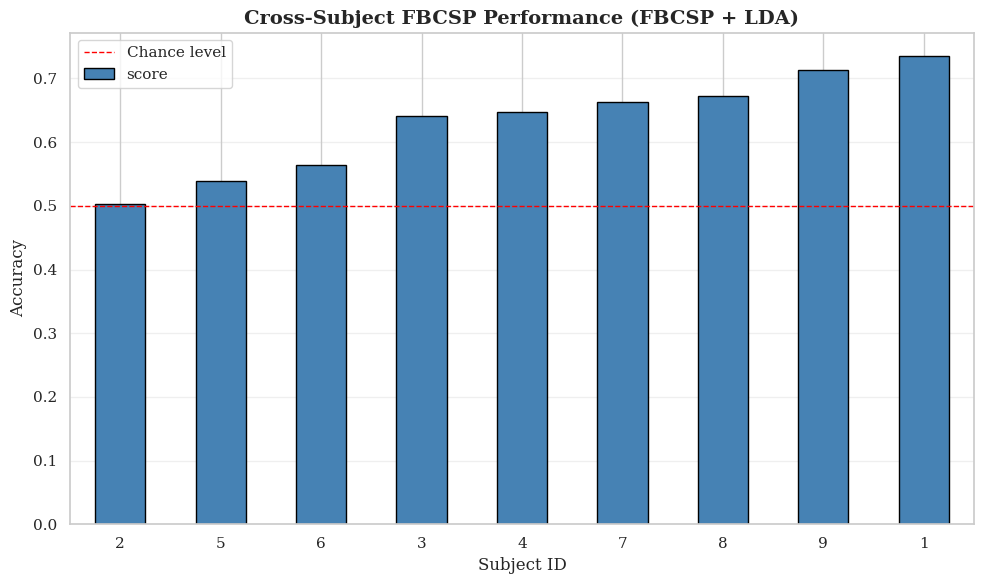

[2026-04-14 10:18:25] Saved plot: /Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/artifacts/03_fbcsp_lda/performance_distribution_boxplot.png


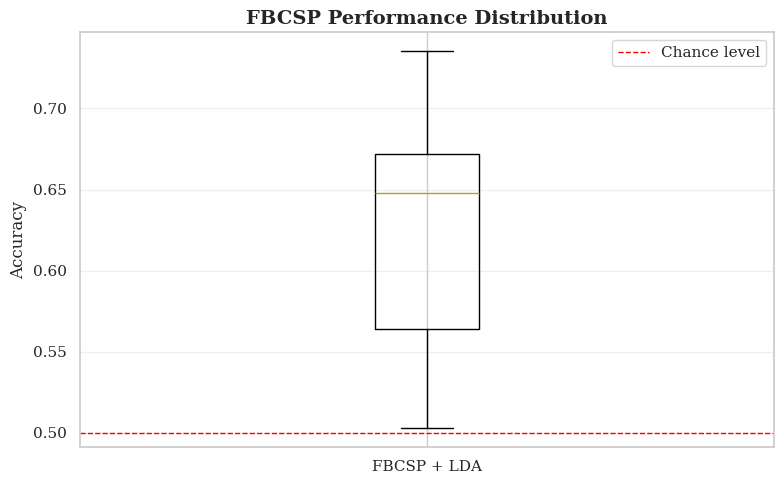

In [14]:
plt.figure(figsize=(10, 6))
per_subject_scores.plot(kind='bar', color='steelblue', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Subject FBCSP Performance (FBCSP + LDA)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('per_subject_accuracy_bar.png')
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([per_subject_scores.values], labels=['FBCSP + LDA'])
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.ylabel('Accuracy', fontsize=12)
plt.title('FBCSP Performance Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('performance_distribution_boxplot.png')
plt.show()